# DBMS Module B: B+ Tree vs PostgreSQL Benchmarks

This notebook provides a professional benchmarking suite to compare the performance of our custom **C++ B+ Tree implementation (Module B)** against **PostgreSQL's B-Tree indexing**.

### Benchmarked Operations:
1. **Bulk Insert**: Inserting a large dataset.
2. **Point Select**: Finding a single record by key.
3. **Search Miss**: Searching for non-existent keys.
4. **Range Select**: Retrieving all records within a key range.
5. **Update**: Modifying existing records.
6. **Delete**: Removing records from the index.

Results are saved to `benchmark_results.csv` for further analysis.

In [2]:
%pip install psycopg2 --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for psycopg2: filename=psycopg2-2.9.11-cp314-cp314-linux_x86_64.whl size=557743 sha256=e77d2b4c9cef64242536997c9840c9f5cb75058505b714d0cb0bae0e59e3baaf
  Stored in directory: /home/anurag/.cache/pip/wheels/07/65/9d/ea45a1a14ac8f39266a738e13d40caad5ae067b9f216f1992d
Successfully built psycopg2
Note: you may need to restart the kernel to use updated packages.


In [3]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import numpy as np

# Add current directory to path for imports
sys.path.append(os.getcwd())
from bplustree import BPlusTree
from db import get_connection

## 1. Setup Benchmark Table
We create a dedicated table in PostgreSQL for benchmarking to avoid interfering with production data.

In [4]:
def setup_pg_table():
    conn = get_connection()
    cur = conn.cursor()
    try:
        cur.execute("DROP TABLE IF EXISTS freshwash.benchmark_test CASCADE")
        cur.execute("""
            CREATE TABLE freshwash.benchmark_test (
                id INT PRIMARY KEY,
                value TEXT
            )
        """)
        conn.commit()
        print("Benchmark table created.")
    except Exception as e:
        conn.rollback()
        print(f"Error: {e}")
    finally:
        cur.close()
        conn.close()

setup_pg_table()

Benchmark table created.


## 2. Benchmark Runner
We define a class to handle benchmarking logic for both engines.

In [5]:
class BenchmarkRunner:
    def __init__(self, data_size):
        self.data_size = data_size
        self.test_keys = list(range(1, data_size + 1))
        random.shuffle(self.test_keys)
        self.data = [(k, f"Value_{k}") for k in self.test_keys]
        
    def run_pg_benchmarks(self):
        results = []
        conn = get_connection()
        cur = conn.cursor()
        
        # 1. Insert
        start = time.perf_counter()
        cur.executemany("INSERT INTO freshwash.benchmark_test (id, value) VALUES (%s, %s)", self.data)
        conn.commit()
        results.append({"Engine": "PostgreSQL", "Data Size": self.data_size, "Operation": "INSERT", "Time (ms)": (time.perf_counter() - start) * 1000})
        
        # 2. Select (Point)
        sample_keys = random.sample(self.test_keys, min(1000, self.data_size))
        start = time.perf_counter()
        for k in sample_keys:
            cur.execute("SELECT value FROM freshwash.benchmark_test WHERE id = %s", (k,))
            cur.fetchone()
        results.append({"Engine": "PostgreSQL", "Data Size": self.data_size, "Operation": "SELECT_POINT", "Time (ms)": ((time.perf_counter() - start) * 1000) / len(sample_keys) * self.data_size})
        
        # 2b. Select (Miss)
        miss_keys = list(range(self.data_size + 1, self.data_size + 1001))
        start = time.perf_counter()
        for k in miss_keys:
            cur.execute("SELECT value FROM freshwash.benchmark_test WHERE id = %s", (k,))
            cur.fetchone()
        results.append({"Engine": "PostgreSQL", "Data Size": self.data_size, "Operation": "SELECT_MISS", "Time (ms)": ((time.perf_counter() - start) * 1000) / len(miss_keys) * self.data_size})
        
        # 3. Range Query
        num_ranges = 50
        ranges = []
        for _ in range(num_ranges):
            s = random.randint(1, self.data_size - 100)
            ranges.append((s, s + 100))
        
        start = time.perf_counter()
        for s, e in ranges:
            cur.execute("SELECT * FROM freshwash.benchmark_test WHERE id BETWEEN %s AND %s", (s, e))
            cur.fetchall()
        results.append({"Engine": "PostgreSQL", "Data Size": self.data_size, "Operation": "SELECT_RANGE", "Time (ms)": ((time.perf_counter() - start) * 1000) / num_ranges})
        
        # 4. Update
        start = time.perf_counter()
        update_data = [(f"NewValue_{k}", k) for k in sample_keys]
        cur.executemany("UPDATE freshwash.benchmark_test SET value = %s WHERE id = %s", update_data)
        conn.commit()
        results.append({"Engine": "PostgreSQL", "Data Size": self.data_size, "Operation": "UPDATE", "Time (ms)": ((time.perf_counter() - start) * 1000) / len(sample_keys) * self.data_size})
        
        # 5. Delete
        start = time.perf_counter()
        cur.execute("DELETE FROM freshwash.benchmark_test")
        conn.commit()
        results.append({"Engine": "PostgreSQL", "Data Size": self.data_size, "Operation": "DELETE_ALL", "Time (ms)": (time.perf_counter() - start) * 1000})
        
        cur.close()
        conn.close()
        return results

    def run_bplus_benchmarks(self):
        results = []
        tree = BPlusTree(order=64)
        
        # 1. Insert
        start = time.perf_counter()
        for k, v in self.data:
            tree.insert(k, v)
        results.append({"Engine": "Module B B+ Tree", "Data Size": self.data_size, "Operation": "INSERT", "Time (ms)": (time.perf_counter() - start) * 1000})
        
        # 2. Select (Point)
        sample_keys = random.sample(self.test_keys, min(1000, self.data_size))
        start = time.perf_counter()
        for k in sample_keys:
            tree.search(k)
        results.append({"Engine": "Module B B+ Tree", "Data Size": self.data_size, "Operation": "SELECT_POINT", "Time (ms)": ((time.perf_counter() - start) * 1000) / len(sample_keys) * self.data_size})
        
        # 2b. Select (Miss)
        miss_keys = list(range(self.data_size + 1, self.data_size + 1001))
        start = time.perf_counter()
        for k in miss_keys:
            tree.search(k)
        results.append({"Engine": "Module B B+ Tree", "Data Size": self.data_size, "Operation": "SELECT_MISS", "Time (ms)": ((time.perf_counter() - start) * 1000) / len(miss_keys) * self.data_size})
        
        # 3. Range Query
        num_ranges = 50
        ranges = []
        for _ in range(num_ranges):
            s = random.randint(1, self.data_size - 100)
            ranges.append((s, s + 100))
        
        start = time.perf_counter()
        for s, e in ranges:
            tree.range_query(s, e)
        results.append({"Engine": "Module B B+ Tree", "Data Size": self.data_size, "Operation": "SELECT_RANGE", "Time (ms)": ((time.perf_counter() - start) * 1000) / num_ranges})
        
        # 4. Update
        start = time.perf_counter()
        for k in sample_keys:
            tree.update(k, f"NewValue_{k}")
        results.append({"Engine": "Module B B+ Tree", "Data Size": self.data_size, "Operation": "UPDATE", "Time (ms)": ((time.perf_counter() - start) * 1000) / len(sample_keys) * self.data_size})
        
        # 5. Delete
        start = time.perf_counter()
        for k in self.test_keys:
            tree.delete(k)
        results.append({"Engine": "Module B B+ Tree", "Data Size": self.data_size, "Operation": "DELETE_ALL", "Time (ms)": (time.perf_counter() - start) * 1000})
        
        return results

## 3. Run Experiments
We run the benchmarks across different data sizes and collect the data.

In [11]:
data_sizes = [1000, 5000, 10000, 20000]
all_results = []

for size in data_sizes:
    print(f"Benchmarking data size: {size}...")
    runner = BenchmarkRunner(size)
    all_results.extend(runner.run_pg_benchmarks())
    all_results.extend(runner.run_bplus_benchmarks())

df = pd.DataFrame(all_results)
df.to_csv('benchmark_results.csv', index=False)
print("\nBenchmarks complete. Results saved to benchmark_results.csv")

display(df.head(10))

Benchmarking data size: 1000...
Benchmarking data size: 5000...
Benchmarking data size: 10000...
Benchmarking data size: 20000...

Benchmarks complete. Results saved to benchmark_results.csv


,Engine,Data Size,Operation,Time (ms)
0,PostgreSQL,1000,INSERT,33.515965
1,PostgreSQL,1000,SELECT_POINT,36.295963
2,PostgreSQL,1000,SELECT_MISS,35.151843
3,PostgreSQL,1000,SELECT_RANGE,0.078208
4,PostgreSQL,1000,UPDATE,53.051224
5,PostgreSQL,1000,DELETE_ALL,3.478818
6,Module B B+ Tree,1000,INSERT,2.332855
7,Module B B+ Tree,1000,SELECT_POINT,1.784179
8,Module B B+ Tree,1000,SELECT_MISS,1.392879
9,Module B B+ Tree,1000,SELECT_RANGE,0.110813


## 4. Visual Analysis
We visualize the performance difference between the custom storage engine (in-memory B+ Tree) and the persistent database (PostgreSQL).

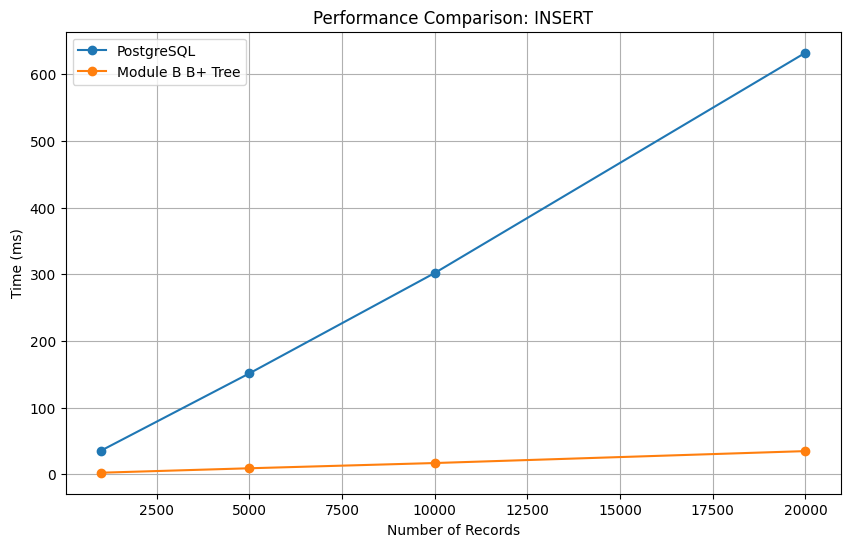

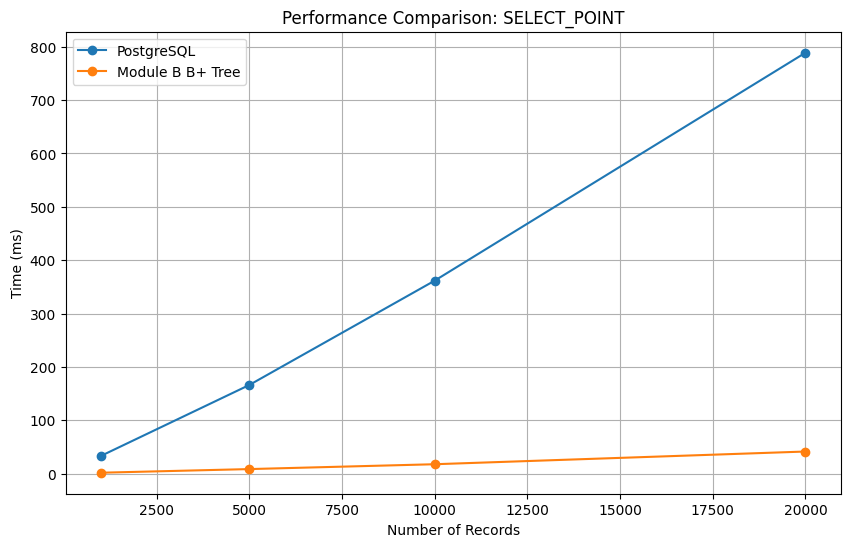

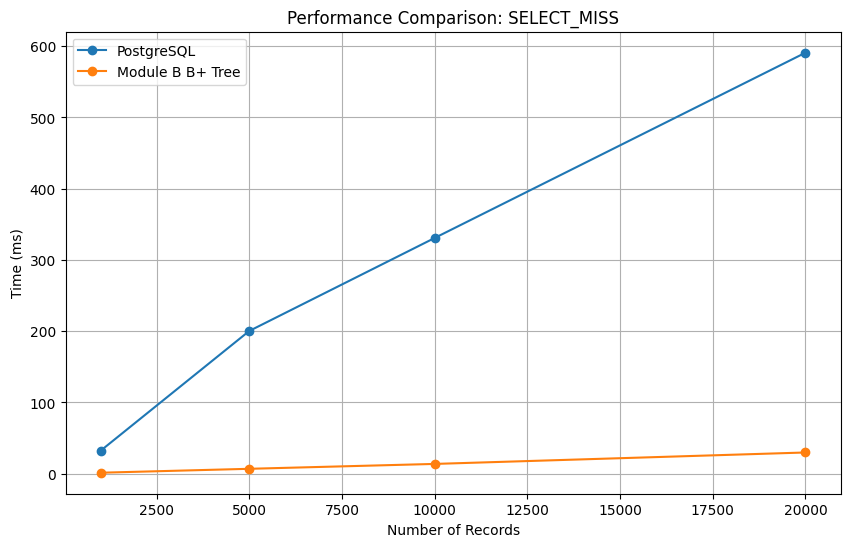

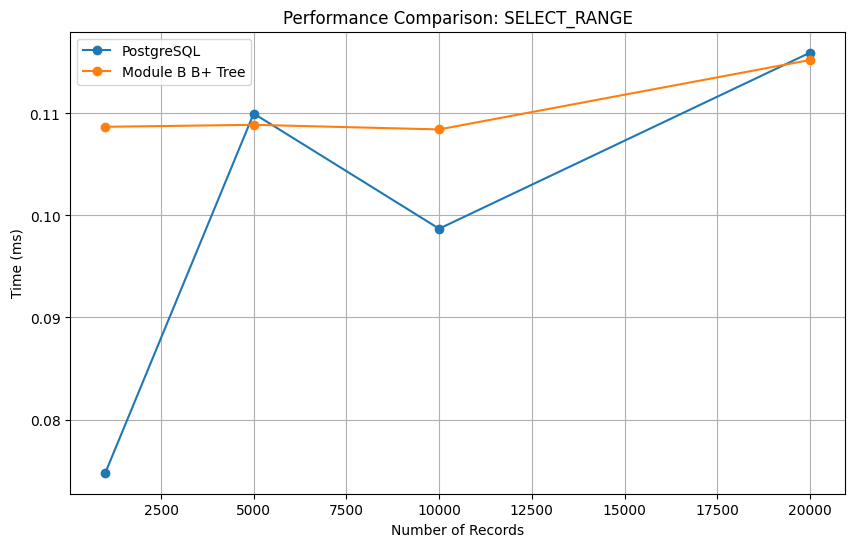

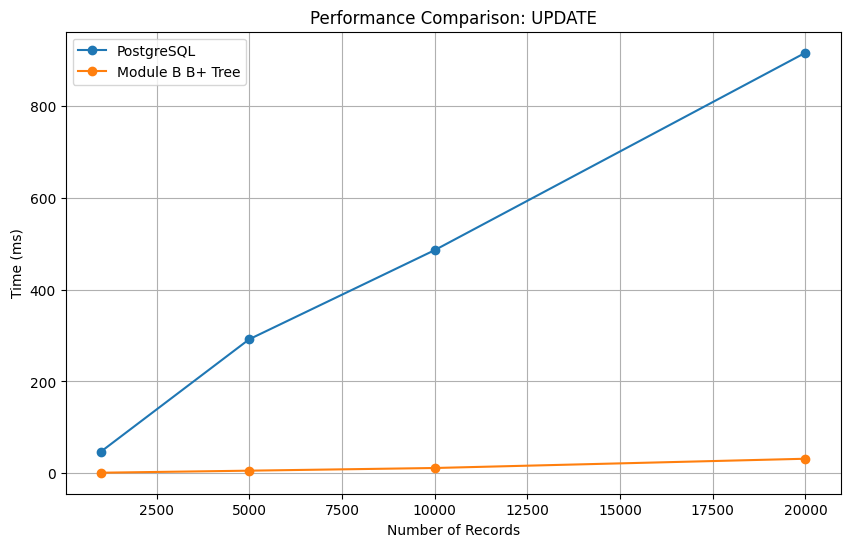

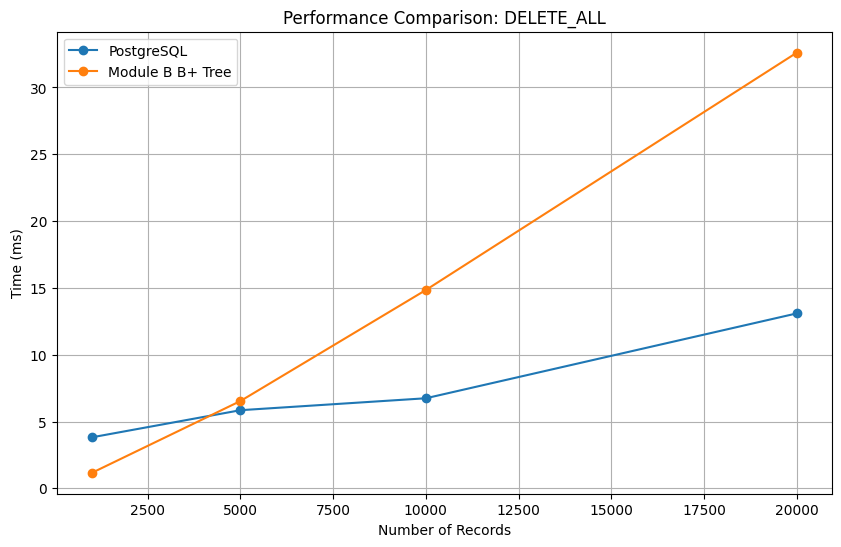

In [8]:
def plot_results(df, operation):
    plot_df = df[df['Operation'] == operation]
    plt.figure(figsize=(10, 6))
    for engine in plot_df['Engine'].unique():
        subset = plot_df[plot_df['Engine'] == engine]
        plt.plot(subset['Data Size'], subset['Time (ms)'], marker='o', label=engine)
    
    plt.title(f'Performance Comparison: {operation}')
    plt.xlabel('Number of Records')
    plt.ylabel('Time (ms)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'benchmark_{operation.lower()}.png')
    plt.show()

operations = df['Operation'].unique()
for op in operations:
    plot_results(df, op)

## 5. Summary Statistics
Calculate the average speedup factor for Module B over PostgreSQL.

In [9]:
pivot_df = df.pivot_table(index=['Operation', 'Data Size'], columns='Engine', values='Time (ms)')
pivot_df['Speedup (x)'] = pivot_df['PostgreSQL'] / pivot_df['Module B B+ Tree']
pivot_df

Engine                  Module B B+ Tree  PostgreSQL  Speedup (x)
Operation    Data Size                                           
DELETE_ALL   1000               1.170017    3.821802     3.266450
             5000               6.535143    5.848506     0.894932
             10000             14.840446    6.741332     0.454254
             20000             32.595200   13.089061     0.401564
INSERT       1000               2.420578   35.404770    14.626577
             5000               9.084843  151.224527    16.645805
             10000             16.941319  301.717144    17.809543
             20000             34.823194  632.027471    18.149612
SELECT_MISS  1000               1.338746   32.509066    24.283222
             5000               6.838905  200.261005    29.282612
             10000             13.689030  330.806040    24.165777
             20000             29.748740  590.868440    19.861965
SELECT_POINT 1000               1.640326   33.098589    20.178055
             5000               8.457260  165.962785    19.623706
             10000             17.546910  361.498780    20.601848
             20000             41.365860  788.731820    19.067217
SELECT_RANGE 1000               0.108688    0.074785     0.688072
             5000               0.108883    0.109989     1.010149
             10000              0.108432    0.098701     0.910257
             20000              0.115235    0.115949     1.006201
UPDATE       1000               1.053237   46.929820    44.557702
             5000               5.521570  291.988750    52.881472
             10000             11.347920  486.233360    42.847796
             20000             31.527480  916.716720    29.076752